<a href="https://colab.research.google.com/github/manasvisrivastava-25BAI/EDA-LAB/blob/main/eda_lab8_15.9.26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage
from wordcloud import WordCloud
from pandas.plotting import parallel_coordinates, andrews_curves


In [28]:
data = {"Name" : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'],
        "Study hours" : [2,3,6,4,7,8,5,2,1,3],
        "Attendance" : [55, 60, 75, 80, 90, 56, 67, 76, 87, 91],
        "Math" : [30,40,23,43,49,50,32,39,40,45],
        "English" : [45,42,43,41,39,35,33,35,20,48],
        "Grade" : ["A", "A", "B", "A", "B", "D", "C", "B", "B", "A"]}
df = pd.DataFrame(data)
df

,Name,Study hours,Attendance,Math,English,Grade
0,a,2,55,30,45,A
1,b,3,60,40,42,A
2,c,6,75,23,43,B
3,d,4,80,43,41,A
4,e,7,90,49,39,B
5,f,8,56,50,35,D
6,g,5,67,32,33,C
7,h,2,76,39,35,B
8,i,1,87,40,20,B
9,j,3,91,45,48,A


In [29]:
print(df.shape)

(10, 6)


In [30]:
df.describe()

,Study hours,Attendance,Math,English
count,10.000000,10.000000,10.000000,10.000000
mean,4.100000,73.700000,39.100000,38.100000
std,2.330951,13.679262,8.569325,7.936554
min,1.000000,55.000000,23.000000,20.000000
25%,2.250000,61.750000,33.750000,35.000000
50%,3.500000,75.500000,40.000000,40.000000
75%,5.750000,85.250000,44.500000,42.750000
max,8.000000,91.000000,50.000000,48.000000


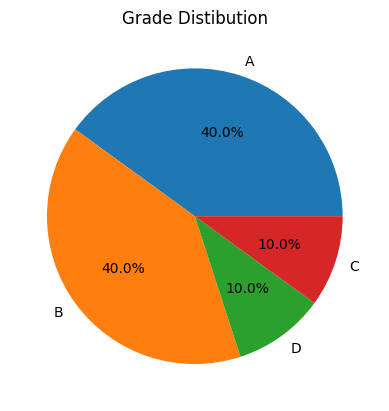

In [31]:
grade_count = df["Grade"].value_counts()
plt.pie(grade_count.values, labels = grade_count.index, autopct = "%1.1f%%")
plt.title("Grade Distibution")
plt.show()

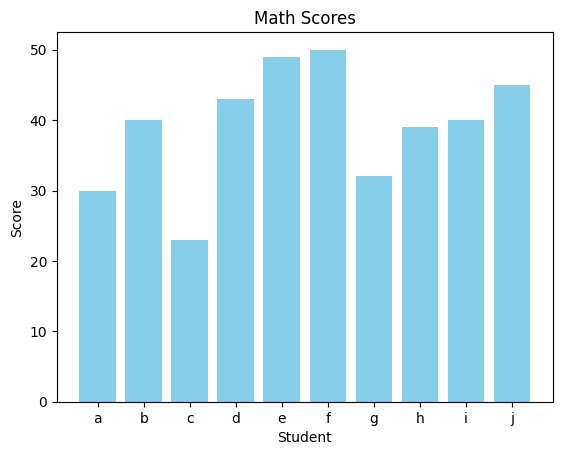

In [32]:
plt.bar(df["Name"], df["Math"], color = "skyblue")
plt.title("Math Scores")
plt.xlabel("Student")
plt.ylabel("Score")
plt.show()

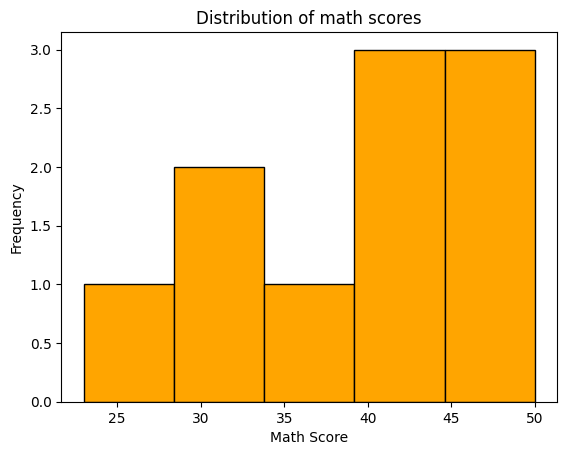

In [33]:
plt.hist(df["Math"], bins = 5, color = "orange", edgecolor = "black")
plt.title("Distribution of math scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

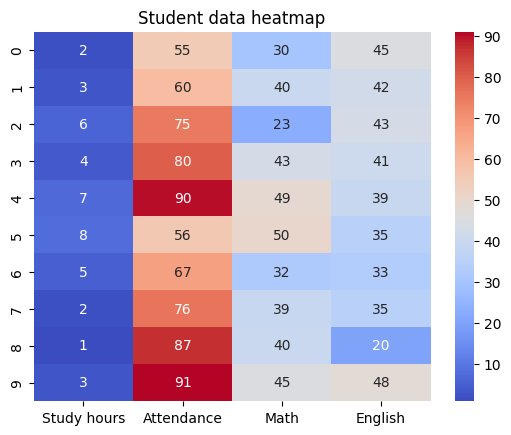

In [34]:
sns.heatmap(df[["Study hours", "Attendance", "Math", "English"]], annot = True, cmap = "coolwarm")
plt.title("Student data heatmap")
plt.show()

In [35]:
df["state"] = ["Tamil Nadu", "Kerala", "Karnataka", "Tamil Nadu", "Uttar Pradesh", "Gujarat", "Kerala", "Goa", "Tamil Nadu", "Odisha"]
df

,Name,Study hours,Attendance,Math,English,Grade,state
0,a,2,55,30,45,A,Tamil Nadu
1,b,3,60,40,42,A,Kerala
2,c,6,75,23,43,B,Karnataka
3,d,4,80,43,41,A,Tamil Nadu
4,e,7,90,49,39,B,Uttar Pradesh
5,f,8,56,50,35,D,Gujarat
6,g,5,67,32,33,C,Kerala
7,h,2,76,39,35,B,Goa
8,i,1,87,40,20,B,Tamil Nadu
9,j,3,91,45,48,A,Odisha


In [36]:
state_score = df.groupby("state")["Math"].mean().reset_index()
state_score

,state,Math
0,Goa,39.000000
1,Gujarat,50.000000
2,Karnataka,23.000000
3,Kerala,36.000000
4,Odisha,45.000000
5,Tamil Nadu,37.666667
6,Uttar Pradesh,49.000000


In [37]:
fig = px.choropleth(state_score,
                        geojson="https://gist.githubusercontent.com/deldersveld/2a57f23fa3c7fdc4c5e5b9c2a6b1d6d5/raw/India_states.geojson",
                     locations = "state",
                    featureidkey = "properties.ST_NM",
                    color = "Math",
                    color_continuous_scale="Viridis",
                    title="Average Math Score by State")
fig.update_geos(fitbounds = "locations", visible = False)
fig.show()

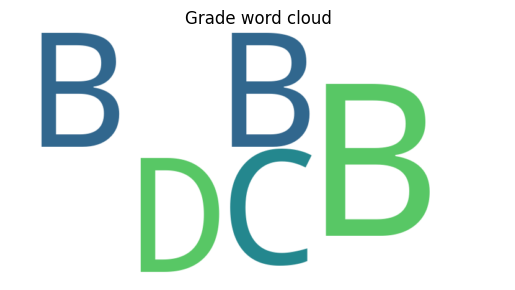

In [38]:
text = " ".join(df["Grade"])
wordcloud = WordCloud(width = 800, height = 400, background_color="white").generate(text)
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Grade word cloud")
plt.show()

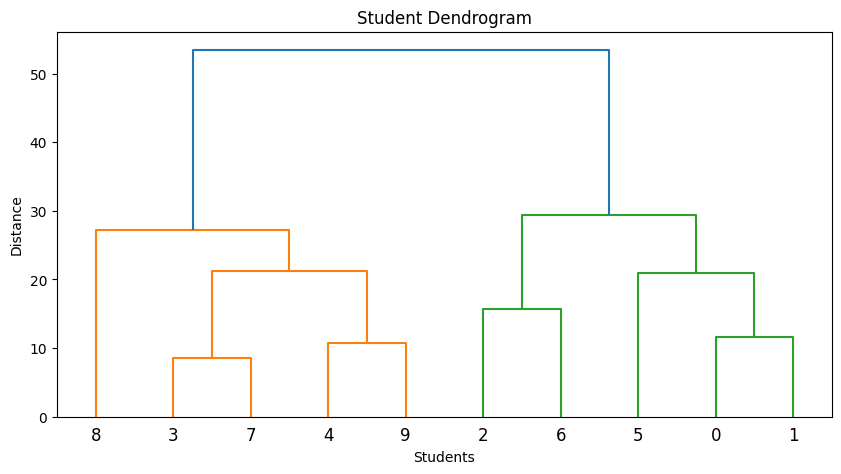

In [39]:
x = df[["Study hours", "Attendance", "Math", "English"]]
linked = linkage(x, method = "ward")
plt.figure(figsize = (10, 5))
dendrogram(linked)
plt.title("Student Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

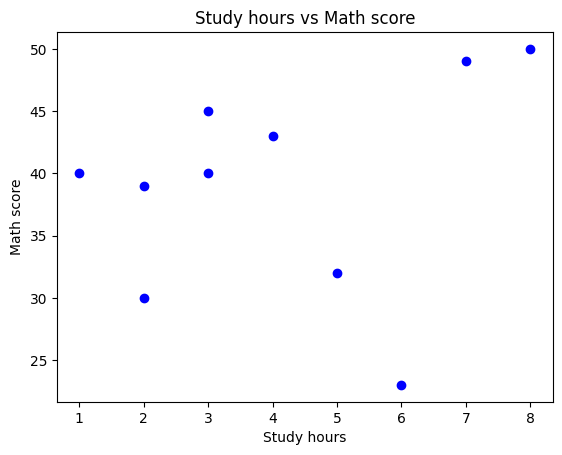

In [40]:
plt.scatter(df["Study hours"], df["Math"], color = "blue")
plt.title("Study hours vs Math score")
plt.xlabel("Study hours")
plt.ylabel("Math score")
plt.show()

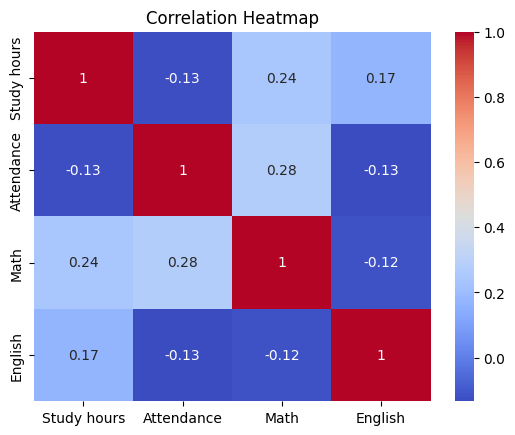

In [41]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

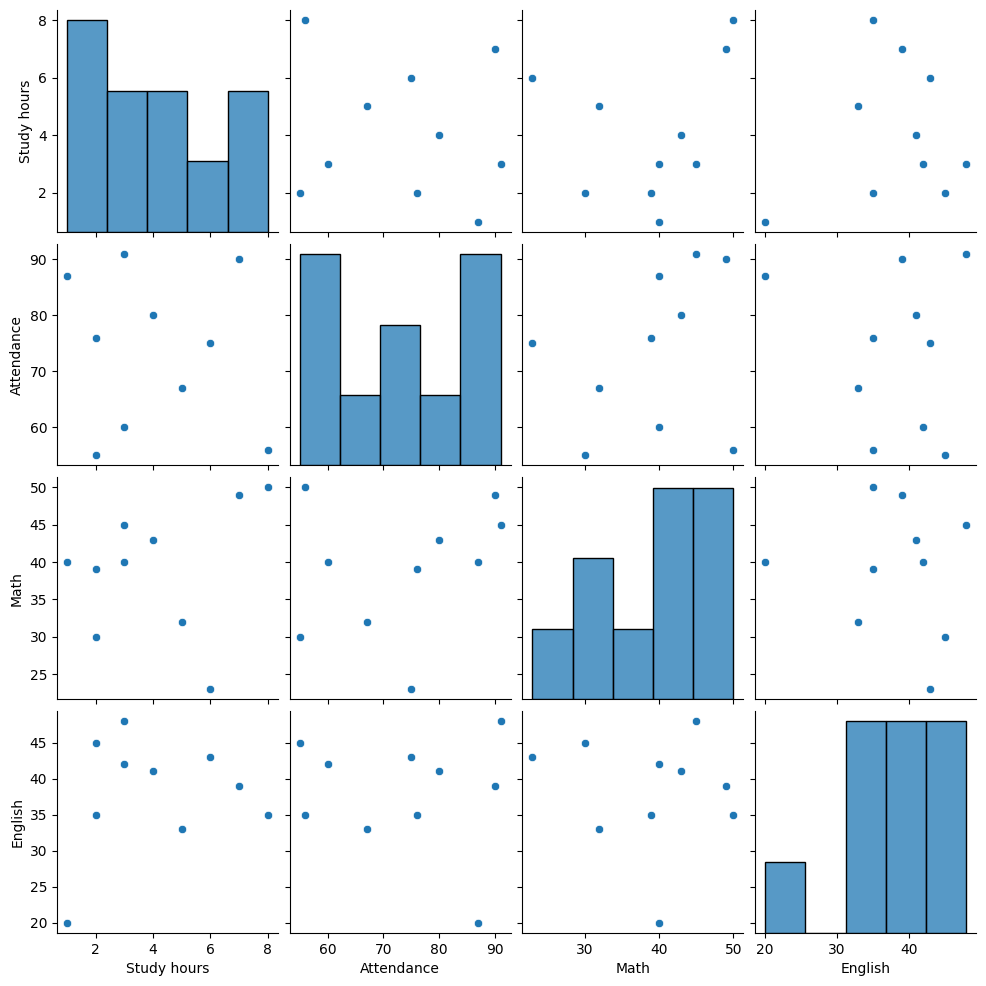

In [42]:
sns.pairplot(df[["Study hours", "Attendance", "Math", "English"]])
plt.show()

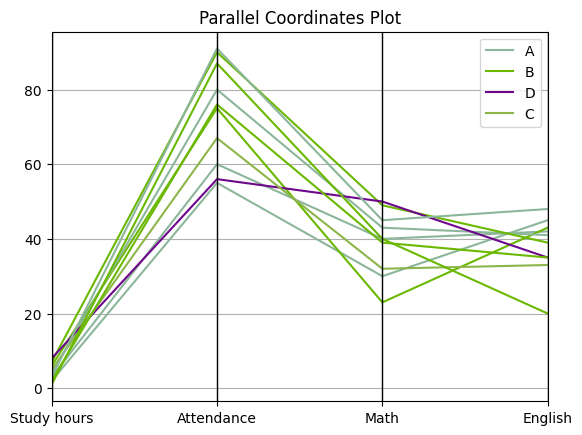

In [43]:
parallel_coordinates(df[["Grade", "Study hours", "Attendance", "Math", "English"]], "Grade")
plt.title("Parallel Coordinates Plot")
plt.show()

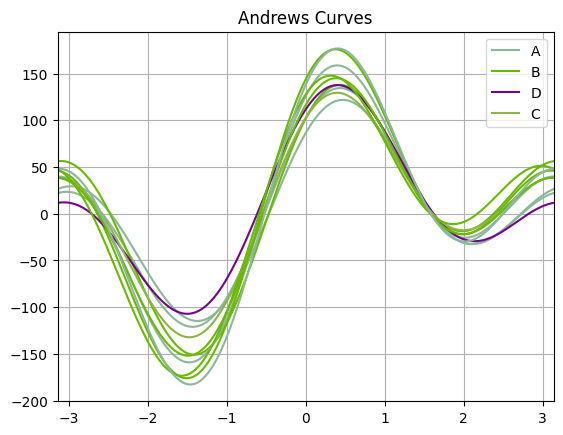

In [44]:
andrews_curves(
    df[["Grade","Study hours","Attendance","Math","English"]],"Grade")

plt.title("Andrews Curves")

plt.show()
